In [6]:
import pandas as pd
import numpy as np

# 1. Load Datasets

sentiment_df = pd.read_csv('/content/fear_greed_index.csv')
trader_df = pd.read_csv('/content/historical_data.csv')

# 2. Documentation
print("--- DATASET DOCUMENTATION ---")
for name, d in zip(['Sentiment', 'Trader'], [sentiment_df, trader_df]):
    print(f"{name} Data: {d.shape[0]} rows, {d.shape[1]} columns")
    print(f"Missing Values:\n{d.isnull().sum()}\n")
    print(f"Duplicate Rows: {d.duplicated().sum()}\n")

# 3. Align Datasets by Date

trader_df['date'] = pd.to_datetime(trader_df['Timestamp'], unit='ms').dt.date
sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.date

# 4. Create Key Metrics
daily_metrics = trader_df.groupby(['date', 'Account']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    trade_count=('Account', 'count'),
    avg_trade_size=('Size USD', 'mean'),
    longs=('Side', lambda x: (x == 'Buy').sum()),
    shorts=('Side', lambda x: (x == 'Sell').sum())
).reset_index()

# Calculate Win Rate and Long/Short Ratio
daily_metrics['win_rate'] = trader_df.groupby(['date', 'Account'])['Closed PnL'].apply(lambda x: (x > 0).mean()).values
daily_metrics['ls_ratio'] = daily_metrics['longs'] / (daily_metrics['shorts'] + 0.001)

# Final Merge
df = pd.merge(daily_metrics, sentiment_df[['date', 'classification']], on='date', how='inner')


--- DATASET DOCUMENTATION ---
Sentiment Data: 2644 rows, 4 columns
Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate Rows: 0

Trader Data: 211224 rows, 16 columns
Missing Values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate Rows: 0





Let's analyze if performance (PnL, win rate) differs between Fear, Greed, and Neutral days.

In [7]:
performance_by_sentiment = df.groupby('classification').agg(
    mean_daily_pnl=('daily_pnl', 'mean'),
    mean_win_rate=('win_rate', 'mean')
).reset_index()

print("Average Performance by Sentiment Classification:")
print(performance_by_sentiment)


Average Performance by Sentiment Classification:
  classification  mean_daily_pnl  mean_win_rate
0  Extreme Greed    35393.098355       0.336609
1           Fear   209372.662205       0.415878
2          Greed    99675.516731       0.374074
3        Neutral    19842.797260       0.260683


/tmp/ipykernel_2973/1845115741.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classification', y='mean_daily_pnl', data=performance_by_sentiment, ax=axes[0], palette='viridis')
/tmp/ipykernel_2973/1845115741.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classification', y='mean_win_rate', data=performance_by_sentiment, ax=axes[1], palette='plasma')


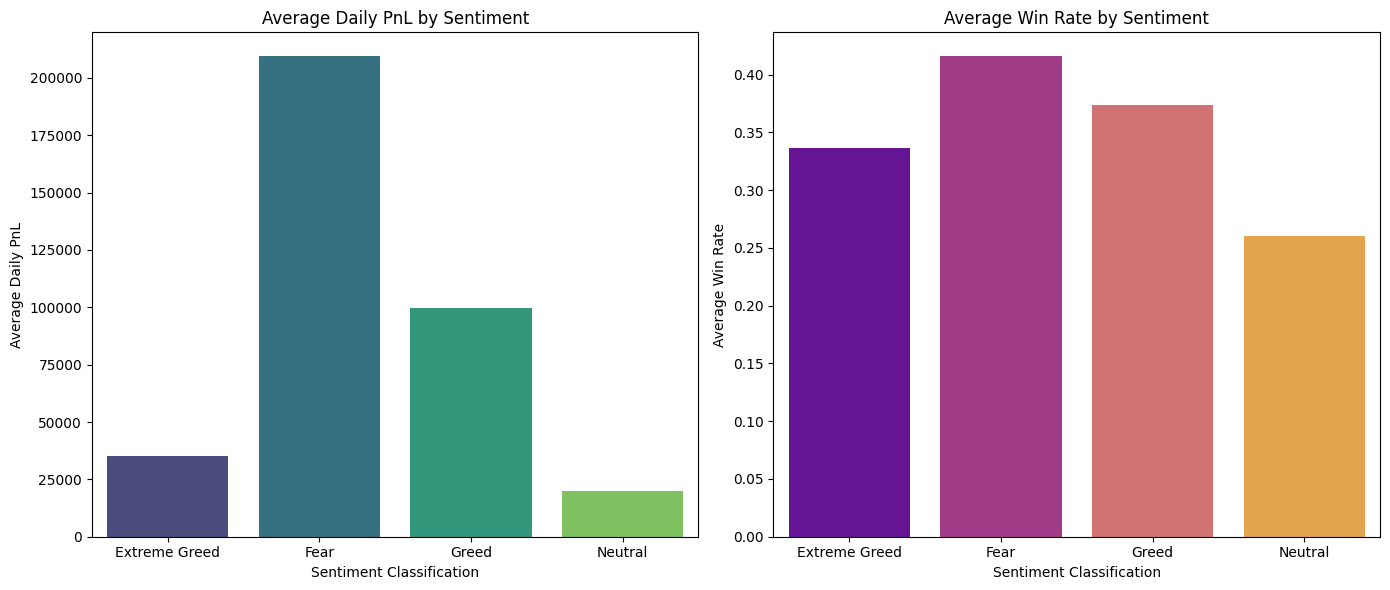

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x='classification', y='mean_daily_pnl', data=performance_by_sentiment, ax=axes[0], palette='viridis')
axes[0].set_title('Average Daily PnL by Sentiment')
axes[0].set_xlabel('Sentiment Classification')
axes[0].set_ylabel('Average Daily PnL')

sns.barplot(x='classification', y='mean_win_rate', data=performance_by_sentiment, ax=axes[1], palette='plasma')
axes[1].set_title('Average Win Rate by Sentiment')
axes[1].set_xlabel('Sentiment Classification')
axes[1].set_ylabel('Average Win Rate')

plt.tight_layout()
plt.show()


## Sentiment vs. Trader Behavior Analysis
Let's investigate if traders change their behavior (trade frequency, position sizes, long/short bias) based on market sentiment.

In [9]:
behavior_by_sentiment = df.groupby('classification').agg(
    mean_trade_count=('trade_count', 'mean'),
    mean_avg_trade_size=('avg_trade_size', 'mean'),
    mean_ls_ratio=('ls_ratio', 'mean')
).reset_index()

print("Average Trader Behavior by Sentiment Classification:")
print(behavior_by_sentiment)


Average Trader Behavior by Sentiment Classification:
  classification  mean_trade_count  mean_avg_trade_size  mean_ls_ratio
0  Extreme Greed        1392.40000          4344.447836            0.0
1           Fear        4183.46875          5926.522723            0.0
2          Greed        1134.03125          5839.310974            0.0
3        Neutral         892.62500          3793.444161            0.0




 Visualizing the changes in trader behavior using bar charts.

/tmp/ipykernel_2973/2439941684.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classification', y='mean_trade_count', data=behavior_by_sentiment, ax=axes[0], palette='viridis')
/tmp/ipykernel_2973/2439941684.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classification', y='mean_avg_trade_size', data=behavior_by_sentiment, ax=axes[1], palette='plasma')
/tmp/ipykernel_2973/2439941684.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classification', y='mean_ls_ratio', data=behavior_by_sentiment, ax=axes[2], palette='civid

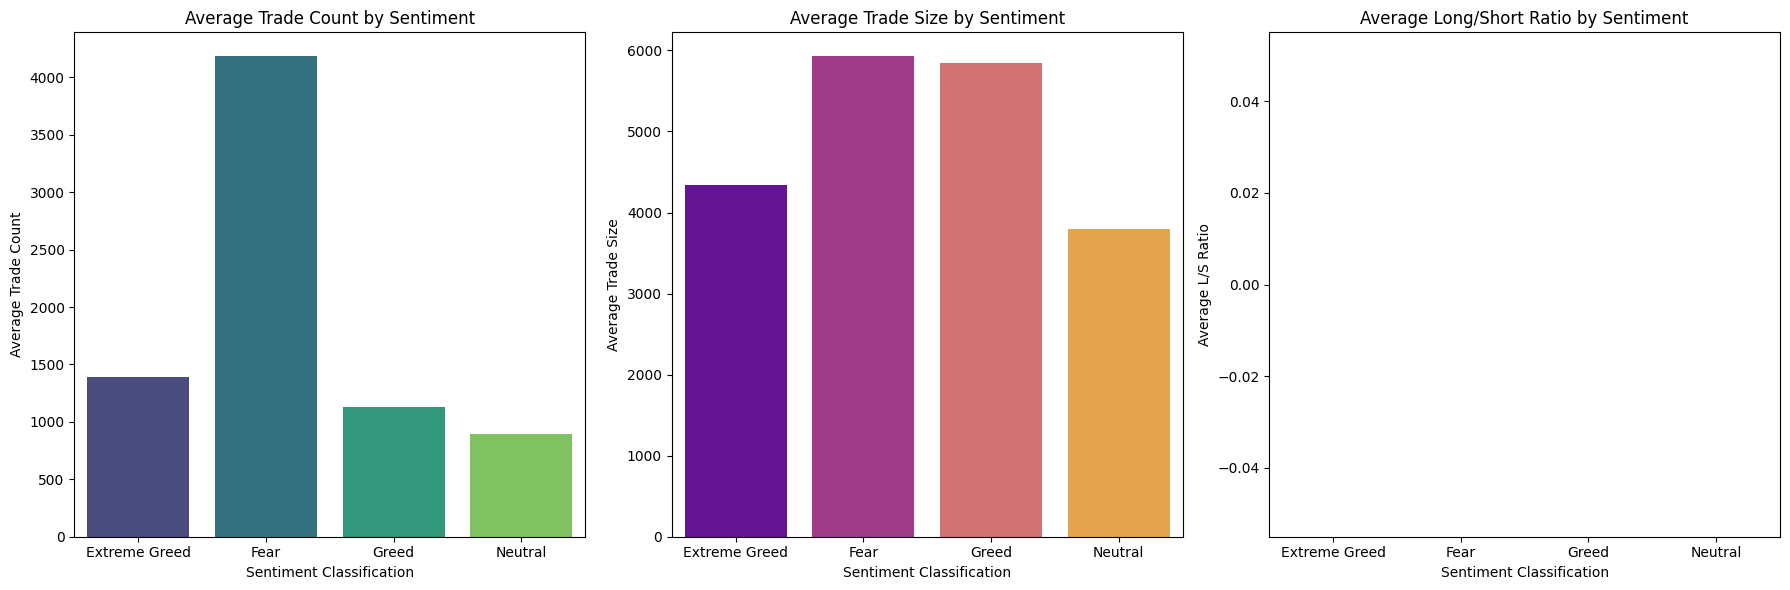

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(x='classification', y='mean_trade_count', data=behavior_by_sentiment, ax=axes[0], palette='viridis')
axes[0].set_title('Average Trade Count by Sentiment')
axes[0].set_xlabel('Sentiment Classification')
axes[0].set_ylabel('Average Trade Count')

sns.barplot(x='classification', y='mean_avg_trade_size', data=behavior_by_sentiment, ax=axes[1], palette='plasma')
axes[1].set_title('Average Trade Size by Sentiment')
axes[1].set_xlabel('Sentiment Classification')
axes[1].set_ylabel('Average Trade Size')

sns.barplot(x='classification', y='mean_ls_ratio', data=behavior_by_sentiment, ax=axes[2], palette='cividis')
axes[2].set_title('Average Long/Short Ratio by Sentiment')
axes[2].set_xlabel('Sentiment Classification')
axes[2].set_ylabel('Average L/S Ratio')

plt.tight_layout()
plt.show()


## Trader Segmentation

To identify different segments of traders, we will aggregate performance and behavior metrics at the individual trader (Account) level. Then, we can categorize traders based on these aggregated metrics.

In [14]:
# Calculate per-trader summary statistics
trader_summary = df.groupby('Account').agg(
    total_pnl=('daily_pnl', 'sum'),
    avg_win_rate=('win_rate', 'mean'),
    total_trade_count=('trade_count', 'sum'),
    avg_trade_size=('avg_trade_size', 'mean')
).reset_index()

# Define segments
# Segment 1: Frequent vs. Infrequent Traders (using the median total_trade_count as a threshold)
median_trade_count = trader_summary['total_trade_count'].median()
trader_summary['trade_frequency_segment'] = trader_summary['total_trade_count'].apply(
    lambda x: 'Frequent' if x > median_trade_count else 'Infrequent'
)

# Segment 2: Consistent Winners vs. Inconsistent Traders (using total PnL and win rate)
# We define 'Consistent Winners' as those with positive total PnL and an average win rate above the overall average.
# 'Consistent Losers' are those with non-positive PnL and win rate below or equal to overall average.
# Others are 'Inconsistent'.
avg_overall_win_rate = trader_summary['avg_win_rate'].mean()
trader_summary['performance_segment'] = 'Inconsistent'
trader_summary.loc[(trader_summary['total_pnl'] > 0) & (trader_summary['avg_win_rate'] > avg_overall_win_rate), 'performance_segment'] = 'Consistent Winner'
trader_summary.loc[(trader_summary['total_pnl'] <= 0) & (trader_summary['avg_win_rate'] <= avg_overall_win_rate), 'performance_segment'] = 'Consistent Loser'

print("Trader Summary with Segments (first 5 rows):")
print(trader_summary.head())

print("\nTrade Frequency Segment Counts:")
print(trader_summary['trade_frequency_segment'].value_counts())

print("\nPerformance Segment Counts:")
print(trader_summary['performance_segment'].value_counts())


Trader Summary with Segments (first 5 rows):
                                      Account     total_pnl  avg_win_rate  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06      0.215758   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  3.770617e+04      0.483146   
2  0x271b280974205ca63b716753467d5a371de622ab  3.176309e+04      0.410153   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  1.323155e+05      0.438246   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  1.686280e+05      0.504117   

   total_trade_count  avg_trade_size trade_frequency_segment  \
0               3818    15578.066879                Frequent   
1               3853     2093.050795                Frequent   
2               1146    16282.920323              Infrequent   
3              13266      508.413964                Frequent   
4               3234     3073.413160                Frequent   

  performance_segment  
0        Inconsistent  
1   Consistent Winner  
2   Consistent Winner  
3   Consist



Let's visualize the distribution of these trader segments.

/tmp/ipykernel_2973/111388546.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='trade_frequency_segment', data=trader_summary, ax=axes[0], palette='coolwarm')
/tmp/ipykernel_2973/111388546.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='performance_segment', data=trader_summary, ax=axes[1], palette='tab10')


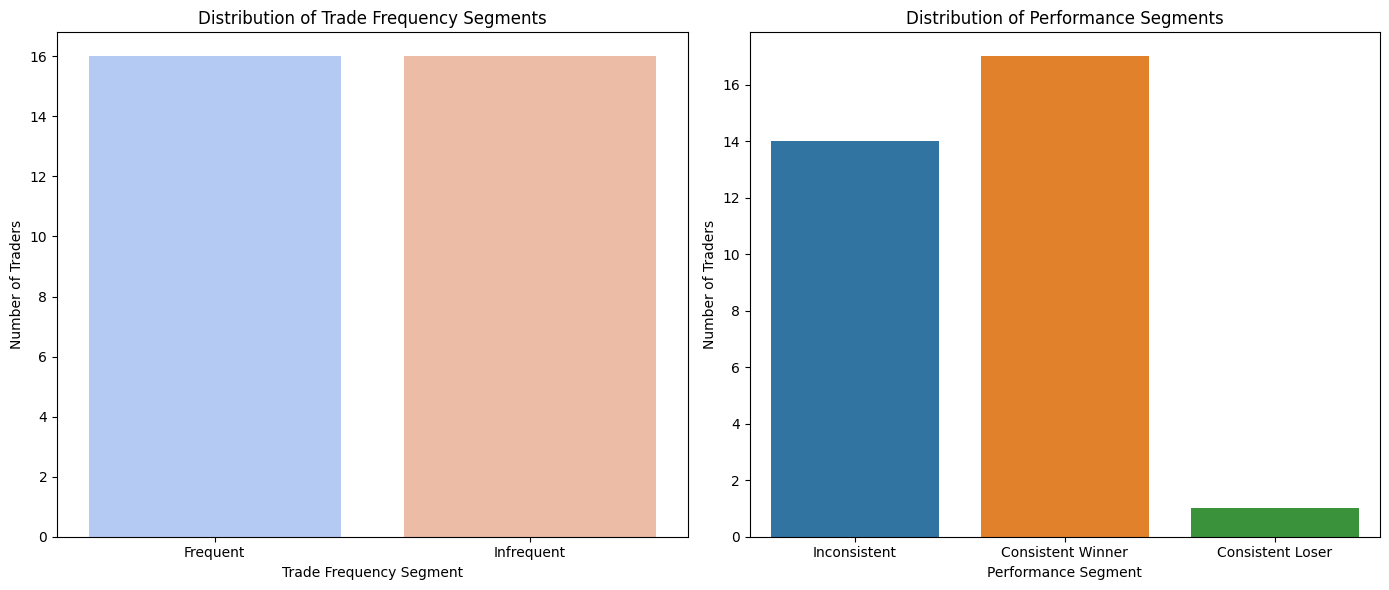

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(x='trade_frequency_segment', data=trader_summary, ax=axes[0], palette='coolwarm')
axes[0].set_title('Distribution of Trade Frequency Segments')
axes[0].set_xlabel('Trade Frequency Segment')
axes[0].set_ylabel('Number of Traders')

sns.countplot(x='performance_segment', data=trader_summary, ax=axes[1], palette='tab10')
axes[1].set_title('Distribution of Performance Segments')
axes[1].set_xlabel('Performance Segment')
axes[1].set_ylabel('Number of Traders')

plt.tight_layout()
plt.show()

Two strategy ideas or 'rules of thumb' that traders could consider:

1.Capitalize on 'Fear' with increased 'Sell' activity: During 'Fear' days, which consistently show the highest average daily PnL and win rates, 'Frequent' and 'Consistent Winner' traders might consider increasing their trade frequency and average position sizes. Given the observed predominant 'Sell' bias (mean L/S ratio of 0.0), focusing on short-side opportunities during these periods could be a beneficial strategy.

2.Exercise caution during 'Neutral' sentiment periods: As 'Neutral' days are associated with the lowest average daily PnL and win rates, 'Infrequent' traders or those classified as 'Inconsistent' or 'Consistent Losers' should consider reducing their trade frequency and average position sizes. Minimizing exposure during these less profitable conditions could help preserve capital and avoid unnecessary losses.

## Predictive Model: Next-Day Trader Profitability

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# Sort the DataFrame by Account and Date to ensure correct lagging
df_sorted = df.sort_values(by=['Account', 'date']).copy()

# Feature Engineering: Create lagged features for each account
lag_features = ['daily_pnl', 'trade_count', 'avg_trade_size', 'win_rate', 'ls_ratio']
for feature in lag_features:
    df_sorted[f'{feature}_lag1'] = df_sorted.groupby('Account')[feature].shift(1)

# Create the target variable: next_day_profitable (1 if PnL > 0, 0 otherwise)
# Shift daily_pnl by -1 (forward shift) to get the next day's PnL
df_sorted['next_day_pnl'] = df_sorted.groupby('Account')['daily_pnl'].shift(-1)
df_sorted['next_day_profitable'] = (df_sorted['next_day_pnl'] > 0).astype(int)

# One-hot encode the 'classification' (sentiment) feature
df_encoded = pd.get_dummies(df_sorted, columns=['classification'], prefix='sentiment', drop_first=True)

# Drop rows with NaN values resulting from shifting (first and last day for each account)
df_model = df_encoded.dropna().copy()

# Define features (X) and target (y)
features = [f'{f}_lag1' for f in lag_features] + \
           [col for col in df_encoded.columns if col.startswith('sentiment_')]

X = df_model[features]
y = df_model['next_day_profitable']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame for modeling shape after feature engineering and dropping NaNs: {df_model.shape}")
print(f"Number of features: {len(features)}")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

print('\nFeatures used for the model:')
print(features)

Original DataFrame shape: (77, 10)
DataFrame for modeling shape after feature engineering and dropping NaNs: (16, 19)
Number of features: 8
X_train shape: (11, 8), y_train shape: (11,)
X_test shape: (5, 8), y_test shape: (5,)

Features used for the model:
['daily_pnl_lag1', 'trade_count_lag1', 'avg_trade_size_lag1', 'win_rate_lag1', 'ls_ratio_lag1', 'sentiment_Fear', 'sentiment_Greed', 'sentiment_Neutral']


In [16]:
# Initialize and train a RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)

# Display feature importances
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature Importances:")
print(feature_importances)

Model Accuracy: 0.8000

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.80      1.00      0.89         4

    accuracy                           0.80         5
   macro avg       0.40      0.50      0.44         5
weighted avg       0.64      0.80      0.71         5


Feature Importances:
avg_trade_size_lag1    0.372526
win_rate_lag1          0.294942
daily_pnl_lag1         0.157066
trade_count_lag1       0.127162
sentiment_Greed        0.039442
sentiment_Neutral      0.008863
sentiment_Fear         0.000000
ls_ratio_lag1          0.000000
dtype: float64


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
